---
## ▶ PART B — MODEL TRAINING
---

At this point the following variables are live in memory from Part A:

| Variable | Shape | Description |
|---|---|---|
| `X_raw_train` | `(N, 160, 2)` | Raw windows — CNN-LSTM train input |
| `y_raw_train` | `(N,)` | Binary stress labels (0=Baseline, 1=Stress) |
| `X_raw_test` | `(M, 160, 2)` | Raw windows — CNN-LSTM test input |
| `y_raw_test` | `(M,)` | Test labels |
| `X_train` | `(N, F)` | Imputed feature matrix — baseline models |
| `X_test` | `(M, F)` | Imputed feature matrix — baseline models |
| `y_train` | `(N,)` | Train labels (from SMOTE-balanced feature table) |
| `feature_cols` | `list` | Feature column names |
| `df_test_clean` | `DataFrame` | Test feature DataFrame with subject IDs |
| `CNN_CLASS_WEIGHTS` | `dict` | `{0: w0, 1: w1}` for CNN-LSTM loss weighting |


# **Install Additional Libraries**

In [ ]:
# These are additional to what preprocessing already installed
!pip install torch torchvision -q
!pip install shap -q
print('✅ Model training libraries installed!')

✅ Model training libraries installed!


In [ ]:
import os, shutil
from google.colab import drive

# If /content/drive exists with stale files, clear it before mounting
if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    shutil.rmtree('/content/drive', ignore_errors=True)

drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


# **Import Additional Libraries**

In [ ]:
# ── Standard (already in preprocessing but re-import for clean session) ────────
import os, pickle, warnings, time, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)

# ── Sklearn — baselines & metrics ─────────────────────────────────────────────
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.calibration     import calibration_curve
from sklearn.metrics         import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve
)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data       import DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('✅ All imports successful!')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU             : {torch.cuda.get_device_name(0)}')
else:
    print('   ⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU')

✅ All imports successful!
   PyTorch version : 2.10.0+cu128
   Device          : cuda
   GPU             : Tesla T4


# **Load All Preprocessed Data**

In [ ]:
# ── Paths — must match what preprocessing saved ───────────────────────────────
PREPROC_PATH = '/content/drive/MyDrive/C1_Preprocessed'
RAW_PATH     = os.path.join(PREPROC_PATH, 'raw_windows')
RESULTS_PATH = '/content/drive/MyDrive/C1_Results'
os.makedirs(RESULTS_PATH, exist_ok=True)

# ── Verify paths exist ────────────────────────────────────────────────────────
for p in [PREPROC_PATH, RAW_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'❌ Not found: {p}\n   Run the preprocessing notebook first.')

# ── Load metadata (produced by preprocessing) ─────────────────────────────────
with open(os.path.join(PREPROC_PATH, 'metadata.pkl'), 'rb') as f:
    meta = pickle.load(f)

FEATURE_COLS      = meta['feature_cols']       # list of 20 feature names
CNN_CLASS_WEIGHTS = meta['cnn_class_weights']  # {0: 0.7675, 1: 1.4346}
WINDOW_SEC        = meta['window_sec']          # 5
UNIFIED_FS        = meta['unified_fs']          # 32
CNN_INPUT_SHAPE   = meta['cnn_input_shape']     # (160, 2)

# ── Feature tables for baseline models ───────────────────────────────────────
# Training: SMOTE-balanced, 11246 rows
# Test:     subject-independent split, 2205 rows
df_train = pd.read_csv(os.path.join(PREPROC_PATH, 'C1_train_balanced_SMOTE.csv'))
df_test  = pd.read_csv(os.path.join(PREPROC_PATH, 'C1_test.csv'))

X_feat_train = df_train[FEATURE_COLS].values.astype(np.float32)  # (11246, 20)
y_feat_train = df_train['label'].values.astype(int)               # (11246,)
X_feat_test  = df_test[FEATURE_COLS].values.astype(np.float32)   # (2205, 20)
y_feat_test  = df_test['label'].values.astype(int)                # (2205,)

# ── Raw windows for CNN-LSTM ──────────────────────────────────────────────────
# Shape: (N, 160, 2)  — 5s @ 32Hz, channel 0=EDA, channel 1=ECG
X_raw_train = np.load(os.path.join(RAW_PATH, 'X_train_raw.npy'))  # (8791, 160, 2)
y_raw_train = np.load(os.path.join(RAW_PATH, 'y_train_raw.npy'))  # (8791,)
X_raw_test  = np.load(os.path.join(RAW_PATH, 'X_test_raw.npy'))   # (2205, 160, 2)
y_raw_test  = np.load(os.path.join(RAW_PATH, 'y_test_raw.npy'))   # (2205,)

print('✅ All preprocessed data loaded successfully!')
print(f'\n  ── Feature tables (for LR / RF / SVM) ────────────────────')
print(f'  Train (SMOTE) : {X_feat_train.shape}   Labels: B={sum(y_feat_train==0)}, S={sum(y_feat_train==1)}')
print(f'  Test          : {X_feat_test.shape}    Labels: B={sum(y_feat_test==0)},  S={sum(y_feat_test==1)}')
print(f'  Features ({len(FEATURE_COLS)})  : {FEATURE_COLS}')
print(f'\n  ── Raw windows (for CNN-LSTM) ──────────────────────────────')
print(f'  X_train_raw   : {X_raw_train.shape}   ← (N, 160 time-steps, 2 channels)')
print(f'  X_test_raw    : {X_raw_test.shape}    ← (N, 160 time-steps, 2 channels)')
print(f'  CNN input     : {CNN_INPUT_SHAPE}     channel 0=EDA, channel 1=ECG')
print(f'  Class weights : {CNN_CLASS_WEIGHTS}')

✅ All preprocessed data loaded successfully!

  ── Feature tables (for LR / RF / SVM) ────────────────────
  Train (SMOTE) : (11246, 20)   Labels: B=5623, S=5623
  Test          : (2205, 20)    Labels: B=1404,  S=801
  Features (20)  : ['eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_range', 'eda_slope', 'eda_num_peaks', 'eda_peak_amplitude', 'eda_phasic_mean', 'eda_phasic_std', 'eda_phasic_max', 'eda_tonic_mean', 'ecg_mean_rr', 'ecg_std_rr', 'ecg_min_rr', 'ecg_max_rr', 'ecg_heart_rate', 'ecg_hrv_sdnn', 'ecg_hrv_rmssd', 'ecg_hrv_pnn50']

  ── Raw windows (for CNN-LSTM) ──────────────────────────────
  X_train_raw   : (8791, 160, 2)   ← (N, 160 time-steps, 2 channels)
  X_test_raw    : (2205, 160, 2)    ← (N, 160 time-steps, 2 channels)
  CNN input     : (160, 2)     channel 0=EDA, channel 1=ECG
  Class weights : {0: 0.7675048018159595, 1: 1.4345626631853785}


# **Shared Evaluation Utilities**

In [ ]:
# ── Master results registry ───────────────────────────────────────────────────
ALL_RESULTS = {}   # model_name → dict of metrics + raw arrays


def evaluate_model(y_true, y_pred, y_prob, name,
                   inference_ms=None, n_params=None):
    """
    Compute all research metrics and register in ALL_RESULTS.
    Metrics: Accuracy, F1-macro, F1-stress (binary), ROC-AUC.
    """
    rec = {
        'accuracy'    : round(float(accuracy_score(y_true, y_pred)),             4),
        'f1_macro'    : round(float(f1_score(y_true, y_pred, average='macro')),  4),
        'f1_stress'   : round(float(f1_score(y_true, y_pred, average='binary')), 4),
        'roc_auc'     : round(float(roc_auc_score(y_true, y_prob)),              4),
        'inference_ms': round(float(inference_ms), 4) if inference_ms else None,
        'n_params'    : n_params,
        'y_true'      : np.array(y_true),
        'y_pred'      : np.array(y_pred),
        'y_prob'      : np.array(y_prob),
    }
    ALL_RESULTS[name] = rec
    print(f'\n  ┌─ {name}')
    print(f'  │  Accuracy    : {rec["accuracy"]:.4f}')
    print(f'  │  F1 (macro)  : {rec["f1_macro"]:.4f}')
    print(f'  │  F1 (stress) : {rec["f1_stress"]:.4f}')
    print(f'  │  ROC-AUC     : {rec["roc_auc"]:.4f}')
    if inference_ms is not None:
        print(f'  │  Inf ms/win  : {inference_ms:.4f}')
    if n_params is not None:
        print(f'  └  Parameters : {n_params:,}')
    return rec


def plot_confusion(y_true, y_pred, name):
    """Confusion matrix saved to RESULTS_PATH."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Baseline', 'Stress']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH,
                f'cm_{name.replace(" ","_").replace("(","").replace(")","")}.png'),
                dpi=120, bbox_inches='tight')
    plt.show()


def plot_roc_overlay(results_dict, title='ROC Curves — All Models'):
    """Overlay ROC of every registered model in one figure."""
    palette = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))
    plt.figure(figsize=(8, 6))
    for (n, m), col in zip(results_dict.items(), palette):
        fpr, tpr, _ = roc_curve(m['y_true'], m['y_prob'])
        plt.plot(fpr, tpr, lw=2, color=col,
                 label=f'{n}  (AUC={m["roc_auc"]:.3f})')
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'roc_all_models.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ ROC overlay saved.')


print('✅ Evaluation utilities ready!')

✅ Evaluation utilities ready!


---
# **Baseline Models — LR / RF / SVM**

Your proposal (§3 Methodology) requires comparing CNN-LSTM against classical baselines.
All three use `class_weight='balanced'` and operate on the 20-feature table.

| Model | Purpose in research |
|-------|--------------------|
| Logistic Regression | Linear lower-bound baseline |
| Random Forest | Strong tree ensemble — often competitive on tabular physiological features |
| SVM (RBF) | Classic non-linear classifier for biosignal features (literature standard) |

═══════════════════════════════════════════════════════
  BASELINE 1 — Logistic Regression
═══════════════════════════════════════════════════════

  ┌─ Logistic Regression
  │  Accuracy    : 0.7946
  │  F1 (macro)  : 0.7883
  │  F1 (stress) : 0.7518
  │  ROC-AUC     : 0.9223
  │  Inf ms/win  : 0.0056


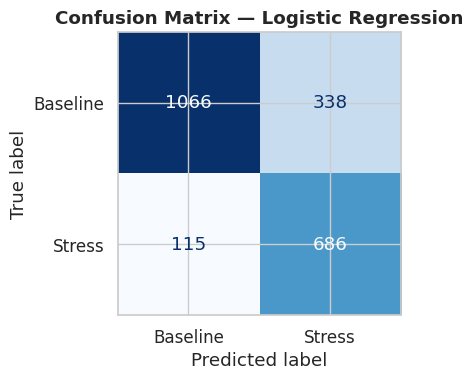

              precision    recall  f1-score   support

    Baseline       0.90      0.76      0.82      1404
      Stress       0.67      0.86      0.75       801

    accuracy                           0.79      2205
   macro avg       0.79      0.81      0.79      2205
weighted avg       0.82      0.79      0.80      2205



In [ ]:
# ════════════════════════════════════════════════════════════
#  BASELINE 1 — Logistic Regression
# ════════════════════════════════════════════════════════════
print('═'*55 + '\n  BASELINE 1 — Logistic Regression\n' + '═'*55)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, max_iter=2000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_SEED
    ))
])
lr_pipe.fit(X_feat_train, y_feat_train)

t0      = time.perf_counter()
lr_pred = lr_pipe.predict(X_feat_test)
lr_prob = lr_pipe.predict_proba(X_feat_test)[:, 1]
lr_ms   = (time.perf_counter() - t0) / len(X_feat_test) * 1000

evaluate_model(y_feat_test, lr_pred, lr_prob, 'Logistic Regression', lr_ms)
plot_confusion(y_feat_test, lr_pred, 'Logistic Regression')
print(classification_report(y_feat_test, lr_pred,
                             target_names=['Baseline', 'Stress']))

═══════════════════════════════════════════════════════
  BASELINE 2 — Random Forest
═══════════════════════════════════════════════════════

  ┌─ Random Forest
  │  Accuracy    : 0.8023
  │  F1 (macro)  : 0.7965
  │  F1 (stress) : 0.7623
  │  ROC-AUC     : 0.8646
  │  Inf ms/win  : 0.1217


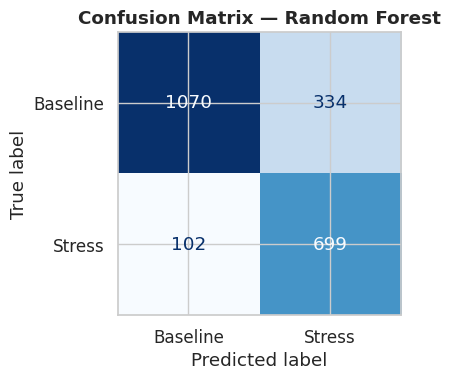

              precision    recall  f1-score   support

    Baseline       0.91      0.76      0.83      1404
      Stress       0.68      0.87      0.76       801

    accuracy                           0.80      2205
   macro avg       0.79      0.82      0.80      2205
weighted avg       0.83      0.80      0.81      2205



In [ ]:
# ════════════════════════════════════════════════════════════
#  BASELINE 2 — Random Forest
# ════════════════════════════════════════════════════════════
print('═'*55 + '\n  BASELINE 2 — Random Forest\n' + '═'*55)

rf_clf = RandomForestClassifier(
    n_estimators   = 300,
    max_depth      = None,
    min_samples_leaf = 2,
    max_features   = 'sqrt',
    class_weight   = 'balanced',
    n_jobs         = -1,
    random_state   = RANDOM_SEED
)
rf_clf.fit(X_feat_train, y_feat_train)

t0      = time.perf_counter()
rf_pred = rf_clf.predict(X_feat_test)
rf_prob = rf_clf.predict_proba(X_feat_test)[:, 1]
rf_ms   = (time.perf_counter() - t0) / len(X_feat_test) * 1000

evaluate_model(y_feat_test, rf_pred, rf_prob, 'Random Forest', rf_ms)
plot_confusion(y_feat_test, rf_pred, 'Random Forest')
print(classification_report(y_feat_test, rf_pred,
                             target_names=['Baseline', 'Stress']))

═══════════════════════════════════════════════════════
  BASELINE 3 — SVM (RBF)
═══════════════════════════════════════════════════════

  ┌─ SVM (RBF)
  │  Accuracy    : 0.8381
  │  F1 (macro)  : 0.8290
  │  F1 (stress) : 0.7896
  │  ROC-AUC     : 0.9166
  │  Inf ms/win  : 0.4693


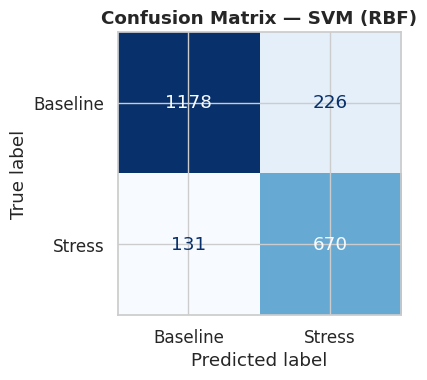

              precision    recall  f1-score   support

    Baseline       0.90      0.84      0.87      1404
      Stress       0.75      0.84      0.79       801

    accuracy                           0.84      2205
   macro avg       0.82      0.84      0.83      2205
weighted avg       0.84      0.84      0.84      2205



In [ ]:
# ════════════════════════════════════════════════════════════
#  BASELINE 3 — SVM (RBF kernel)
# ════════════════════════════════════════════════════════════
print('═'*55 + '\n  BASELINE 3 — SVM (RBF)\n' + '═'*55)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel       = 'rbf',
        C            = 10.0,
        gamma        = 'scale',
        probability  = True,    # required for ROC-AUC
        class_weight = 'balanced',
        random_state = RANDOM_SEED
    ))
])
svm_pipe.fit(X_feat_train, y_feat_train)

t0       = time.perf_counter()
svm_pred = svm_pipe.predict(X_feat_test)
svm_prob = svm_pipe.predict_proba(X_feat_test)[:, 1]
svm_ms   = (time.perf_counter() - t0) / len(X_feat_test) * 1000

evaluate_model(y_feat_test, svm_pred, svm_prob, 'SVM (RBF)', svm_ms)
plot_confusion(y_feat_test, svm_pred, 'SVM (RBF)')
print(classification_report(y_feat_test, svm_pred,
                             target_names=['Baseline', 'Stress']))

In [ ]:
import pickle

# This finds your best model automatically
best_name = max(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['accuracy'])
print(f"✅ Best model is: {best_name}  (Accuracy: {ALL_RESULTS[best_name]['accuracy']})")

# Save the best model
if best_name == 'Logistic Regression':
    best_model = lr_pipe
elif best_name == 'Random Forest':
    best_model = rf_clf
else:
    best_model = svm_pipe

save_path = '/content/drive/MyDrive/C1_Results/best_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(best_model, f)

# Also save the feature column names (needed for prediction)
meta_path = '/content/drive/MyDrive/C1_Results/feature_cols.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

print("✅ Model saved!")
print("✅ Feature columns saved!")

✅ Best model is: SVM (RBF)  (Accuracy: 0.8381)
✅ Model saved!
✅ Feature columns saved!


   TRAINING vs TESTING ACCURACY — ALL MODELS

── Logistic Regression ──
  Metric                    Train        Test         Gap
  ----------------------------------------------------
  Accuracy                 0.8858      0.7946     +0.0913
  F1 (macro)               0.8858      0.7883     +0.0975
  F1 (stress)              0.8840      0.7518     +0.1322
  ROC-AUC                  0.9573      0.9223     +0.0349
  Inference (ms/win): 0.0011
  ✅ Healthy gap (0.0913)

── Random Forest ──
  Metric                    Train        Test         Gap
  ----------------------------------------------------
  Accuracy                 0.9932      0.8023     +0.1910
  F1 (macro)               0.9932      0.7965     +0.1967
  F1 (stress)              0.9932      0.7623     +0.2310
  ROC-AUC                  0.9998      0.8646     +0.1352
  Inference (ms/win): 0.1264
  ⚠️  Overfitting detected! Gap = 0.1910

── SVM (RBF) ──
  Metric                    Train        Test         Gap
  ----------------

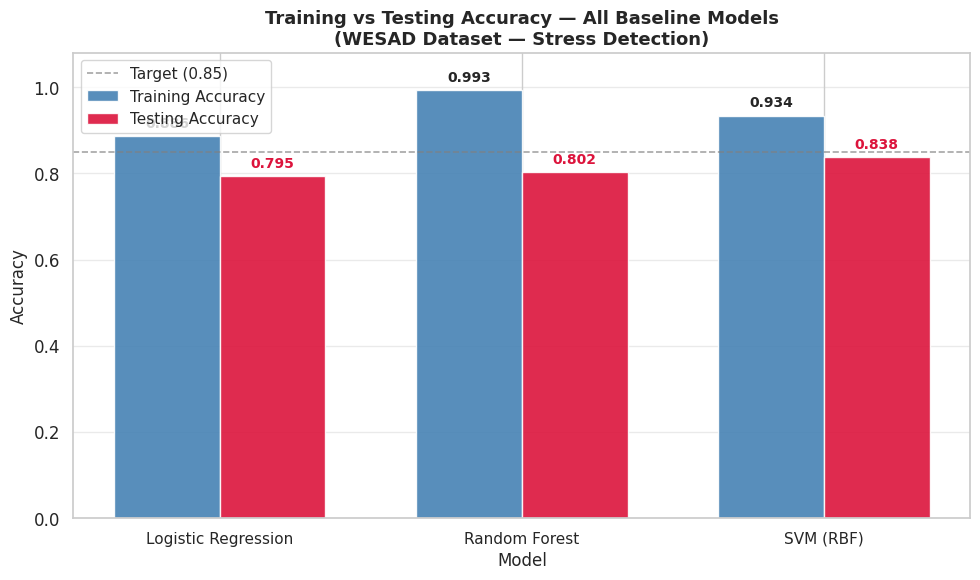


✅ Bar chart saved → train_vs_test_accuracy.png


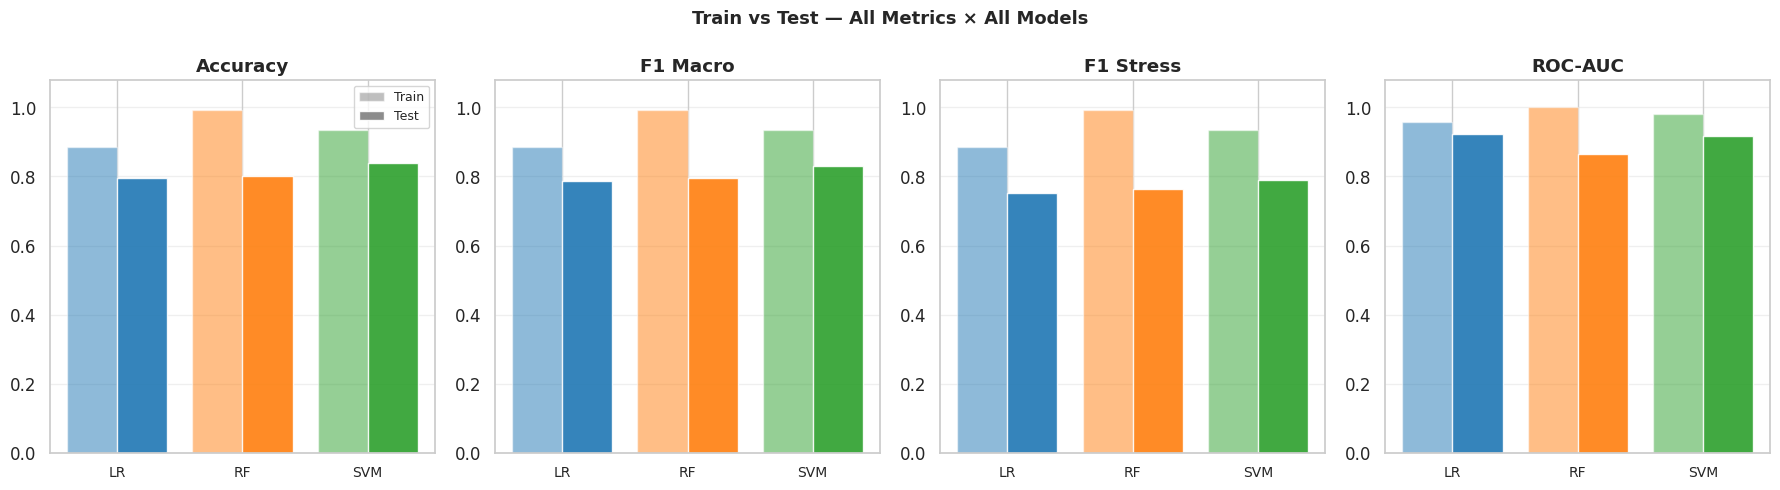

✅ Multi-metric chart saved → all_metrics_train_vs_test.png

🎉 Training & Testing Accuracy Evaluation Complete!


In [ ]:
"""
Training & Testing Accuracy Evaluation
Add this code AFTER your baseline models are trained (after the SVM cell).
It evaluates all 3 models on BOTH train and test sets.
"""

import time
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

RESULTS_PATH = '/content/drive/MyDrive/C1_Results'
os.makedirs(RESULTS_PATH, exist_ok=True)

# ════════════════════════════════════════════════════════════
#  TRAINING & TESTING ACCURACY — ALL BASELINE MODELS
# ════════════════════════════════════════════════════════════

models = {
    'Logistic Regression': lr_pipe,
    'Random Forest':        rf_clf,
    'SVM (RBF)':            svm_pipe,
}

results_summary = {}

print('=' * 65)
print('   TRAINING vs TESTING ACCURACY — ALL MODELS')
print('=' * 65)

for name, model in models.items():
    print(f'\n── {name} ──')

    # ── Training accuracy (on SMOTE-balanced train set) ──────────────────────
    train_pred = model.predict(X_feat_train)
    train_prob = model.predict_proba(X_feat_train)[:, 1]

    train_acc    = accuracy_score(y_feat_train, train_pred)
    train_f1     = f1_score(y_feat_train, train_pred, average='macro')
    train_f1_str = f1_score(y_feat_train, train_pred, average='binary')
    train_auc    = roc_auc_score(y_feat_train, train_prob)

    # ── Testing accuracy (on subject-independent test set) ────────────────────
    t0        = time.perf_counter()
    test_pred = model.predict(X_feat_test)
    test_prob = model.predict_proba(X_feat_test)[:, 1]
    inf_ms    = (time.perf_counter() - t0) / len(X_feat_test) * 1000

    test_acc    = accuracy_score(y_feat_test, test_pred)
    test_f1     = f1_score(y_feat_test, test_pred, average='macro')
    test_f1_str = f1_score(y_feat_test, test_pred, average='binary')
    test_auc    = roc_auc_score(y_feat_test, test_prob)

    # ── Overfitting gap ───────────────────────────────────────────────────────
    gap = train_acc - test_acc

    results_summary[name] = {
        'train_accuracy': train_acc,
        'test_accuracy':  test_acc,
        'train_f1_macro': train_f1,
        'test_f1_macro':  test_f1,
        'train_f1_stress': train_f1_str,
        'test_f1_stress':  test_f1_str,
        'train_roc_auc':  train_auc,
        'test_roc_auc':   test_auc,
        'overfit_gap':    gap,
        'inf_ms':         inf_ms,
    }

    print(f'  {"Metric":<20} {"Train":>10}  {"Test":>10}  {"Gap":>10}')
    print(f'  {"-"*52}')
    print(f'  {"Accuracy":<20} {train_acc:>10.4f}  {test_acc:>10.4f}  {gap:>+10.4f}')
    print(f'  {"F1 (macro)":<20} {train_f1:>10.4f}  {test_f1:>10.4f}  {train_f1-test_f1:>+10.4f}')
    print(f'  {"F1 (stress)":<20} {train_f1_str:>10.4f}  {test_f1_str:>10.4f}  {train_f1_str-test_f1_str:>+10.4f}')
    print(f'  {"ROC-AUC":<20} {train_auc:>10.4f}  {test_auc:>10.4f}  {train_auc-test_auc:>+10.4f}')
    print(f'  Inference (ms/win): {inf_ms:.4f}')

    if gap > 0.10:
        print(f'  ⚠️  Overfitting detected! Gap = {gap:.4f}')
    elif gap < 0.0:
        print(f'  ✅ No overfitting (test > train — good generalization)')
    else:
        print(f'  ✅ Healthy gap ({gap:.4f})')


# ════════════════════════════════════════════════════════════
#  SUMMARY TABLE — Train vs Test Accuracy
# ════════════════════════════════════════════════════════════

print('\n\n' + '=' * 65)
print('   SUMMARY TABLE')
print('=' * 65)
print(f'  {"Model":<22} {"Train Acc":>10}  {"Test Acc":>10}  {"Gap":>8}  {"Test AUC":>10}')
print(f'  {"-"*62}')

for name, r in results_summary.items():
    print(f'  {name:<22} {r["train_accuracy"]:>10.4f}  '
          f'{r["test_accuracy"]:>10.4f}  '
          f'{r["overfit_gap"]:>+8.4f}  '
          f'{r["test_roc_auc"]:>10.4f}')


# ════════════════════════════════════════════════════════════
#  BAR CHART — Training vs Testing Accuracy
# ════════════════════════════════════════════════════════════

model_names  = list(results_summary.keys())
train_accs   = [results_summary[m]['train_accuracy'] for m in model_names]
test_accs    = [results_summary[m]['test_accuracy']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Training Accuracy',
               color='steelblue', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, test_accs,  width, label='Testing Accuracy',
               color='crimson', edgecolor='white', alpha=0.9)

# Add value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='crimson')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training vs Testing Accuracy — All Baseline Models\n(WESAD Dataset — Stress Detection)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.08)
ax.axhline(y=0.85, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Target (0.85)')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'train_vs_test_accuracy.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Bar chart saved → train_vs_test_accuracy.png')


# ════════════════════════════════════════════════════════════
#  MULTI-METRIC COMPARISON (Training AND Testing side-by-side)
# ════════════════════════════════════════════════════════════

metrics = ['Accuracy', 'F1 Macro', 'F1 Stress', 'ROC-AUC']
metric_keys_train = ['train_accuracy', 'train_f1_macro', 'train_f1_stress', 'train_roc_auc']
metric_keys_test  = ['test_accuracy',  'test_f1_macro',  'test_f1_stress',  'test_roc_auc']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Train vs Test — All Metrics × All Models', fontsize=13, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # one colour per model

for i, (metric, key_tr, key_te) in enumerate(zip(metrics, metric_keys_train, metric_keys_test)):
    ax = axes[i]
    x_pos = np.arange(len(model_names))
    tr_vals = [results_summary[m][key_tr] for m in model_names]
    te_vals = [results_summary[m][key_te] for m in model_names]

    ax.bar(x_pos - 0.2, tr_vals, 0.4, label='Train',
           color=colors[:len(model_names)], alpha=0.5, edgecolor='white')
    ax.bar(x_pos + 0.2, te_vals, 0.4, label='Test',
           color=colors[:len(model_names)], alpha=0.9, edgecolor='white')

    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['LR', 'RF', 'SVM'], fontsize=10)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', alpha=0.3)
    if i == 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='gray', alpha=0.5, label='Train'),
                           Patch(facecolor='gray', alpha=0.9, label='Test')]
        ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'all_metrics_train_vs_test.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Multi-metric chart saved → all_metrics_train_vs_test.png')


print('\n🎉 Training & Testing Accuracy Evaluation Complete!')


In [ ]:
# Install needed tools
!pip install flask flask-cors pyngrok -q

from flask import Flask, request, jsonify
from pyngrok import ngrok
import pickle, numpy as np, os, pandas as pd
from flask_cors import CORS

# ── Paths ─────────────────────────────────────────────────────────────────────
PREPROC_PATH = '/content/drive/MyDrive/C1_Preprocessed'
RESULTS_PATH = '/content/drive/MyDrive/C1_Results'
os.makedirs(RESULTS_PATH, exist_ok=True)

MODEL_PATH       = os.path.join(RESULTS_PATH, 'best_model.pkl')
FEAT_COL_PATH    = os.path.join(RESULTS_PATH, 'feature_cols.pkl')
IMPUTER_PATH     = os.path.join(PREPROC_PATH,  'imputer.pkl')
ALL_SUBJECTS_CSV = os.path.join(PREPROC_PATH,  'C1_all_subjects.csv')

# ══════════════════════════════════════════════════════════════════════════════
#  AUTO-TRAIN if best_model.pkl does not exist yet
# ══════════════════════════════════════════════════════════════════════════════
if not os.path.exists(MODEL_PATH):
    print("⚠️  best_model.pkl not found — training now...")

    from sklearn.linear_model  import LogisticRegression
    from sklearn.ensemble      import RandomForestClassifier
    from sklearn.svm           import SVC
    from sklearn.pipeline      import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics       import accuracy_score

    with open(os.path.join(PREPROC_PATH, 'metadata.pkl'), 'rb') as f:
        meta = pickle.load(f)
    FEATURE_COLS = meta['feature_cols']

    df_train = pd.read_csv(os.path.join(PREPROC_PATH, 'C1_train_balanced_SMOTE.csv'))
    df_test  = pd.read_csv(os.path.join(PREPROC_PATH, 'C1_test.csv'))
    X_train  = df_train[FEATURE_COLS].values.astype(np.float32)
    y_train  = df_train['label'].values.astype(int)
    X_test   = df_test[FEATURE_COLS].values.astype(np.float32)
    y_test   = df_test['label'].values.astype(int)

    candidates = {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(C=1.0, max_iter=2000,
                                       class_weight='balanced',
                                       solver='lbfgs', random_state=42))]),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            max_features='sqrt', class_weight='balanced',
            n_jobs=-1, random_state=42),
        'SVM (RBF)': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', C=10.0, gamma='scale',
                        probability=True, class_weight='balanced',
                        random_state=42))]),
    }

    best_name, best_acc, best_model = None, -1, None
    for name, clf in candidates.items():
        print(f"  Training {name}...")
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        print(f"    Accuracy: {acc:.4f}")
        if acc > best_acc:
            best_acc, best_name, best_model = acc, name, clf

    print(f"\n✅ Best model: {best_name}  (accuracy={best_acc:.4f})")
    with open(MODEL_PATH,    'wb') as f: pickle.dump(best_model,   f)
    with open(FEAT_COL_PATH, 'wb') as f: pickle.dump(FEATURE_COLS, f)
    print("✅ Saved best_model.pkl and feature_cols.pkl")
else:
    print("✅ best_model.pkl already exists — skipping training.")

# ══════════════════════════════════════════════════════════════════════════════
#  LOAD MODEL ARTIFACTS
# ══════════════════════════════════════════════════════════════════════════════
with open(MODEL_PATH,    'rb') as f: model        = pickle.load(f)
with open(FEAT_COL_PATH, 'rb') as f: feature_cols = pickle.load(f)
with open(IMPUTER_PATH,  'rb') as f: imputer      = pickle.load(f)
print(f"✅ Model loaded  ({len(feature_cols)} features)")

# ══════════════════════════════════════════════════════════════════════════════
#  LOAD ALL-SUBJECTS CSV and split into per-subject cache
#  The preprocessing pipeline saves one combined CSV: C1_all_subjects.csv
#  with a 'subject' column (S2, S3, … S17 minus S12).
# ══════════════════════════════════════════════════════════════════════════════
if not os.path.exists(ALL_SUBJECTS_CSV):
    raise FileNotFoundError(
        f"❌ {ALL_SUBJECTS_CSV} not found.\n"
        "   Please run the preprocessing cells first to generate this file."
    )

df_all = pd.read_csv(ALL_SUBJECTS_CSV)
print(f"✅ Loaded {ALL_SUBJECTS_CSV}  ({len(df_all)} rows, columns: {list(df_all.columns[:6])} ...)")

# Build per-subject cache from the single combined CSV
subject_data_cache = {}
for sid, grp in df_all.groupby('subject'):
    subject_data_cache[sid] = grp.reset_index(drop=True)
    print(f"  ✅ {sid}: {len(grp)} windows  "
          f"(Baseline={sum(grp.label==0)}, Stress={sum(grp.label==1)})")

print(f"\n✅ {len(subject_data_cache)} subjects ready for prediction!")

# ══════════════════════════════════════════════════════════════════════════════
#  FLASK APP
# ══════════════════════════════════════════════════════════════════════════════
app = Flask(__name__)
CORS(app, origins="*")


@app.route('/predict', methods=['POST'])
def predict():
    body    = request.get_json(force=True)
    subject = body.get('subject', 'S2')
    session = body.get('session', 'Stress Session')

    LABEL_FOR_SESSION = 1 if 'Stress' in session else 0

    features_row = None
    if subject in subject_data_cache:
        df = subject_data_cache[subject]
        filtered = df[df['label'] == LABEL_FOR_SESSION]
        if len(filtered) > 0:
            features_row = filtered.iloc[len(filtered) // 2]  # representative middle window
        else:
            features_row = df.median(numeric_only=True)       # fallback: median of all windows

    # Build feature vector
    if features_row is not None:
        X = np.array([[float(features_row.get(col, 0.0)) for col in feature_cols]])
    else:
        X = np.zeros((1, len(feature_cols)))

    X_imputed = imputer.transform(X)
    pred  = int(model.predict(X_imputed)[0])
    prob  = float(model.predict_proba(X_imputed)[0][1])
    label = "HIGH STRESS" if pred == 1 else "BASELINE"

    def fmt(row, col, unit, decimals=2):
        if row is not None and col in (row.index if hasattr(row, 'index') else []):
            try:
                return f"{round(float(row[col]), decimals)} {unit}"
            except Exception:
                pass
        return "N/A"

    features_display = {
        "mean_eda":       fmt(features_row, 'eda_mean',         '\u03bcS'),
        "eda_peak_count": int(features_row['eda_num_peaks']) if (
            features_row is not None and 'eda_num_peaks' in features_row.index) else 0,
        "phasic_eda":     fmt(features_row, 'eda_phasic_mean',  '\u03bcS'),
        "heart_rate":     fmt(features_row, 'ecg_heart_rate',   'bpm', 1),
        "hrv":            fmt(features_row, 'ecg_hrv_rmssd',    'ms',  1),
        "rr_interval":    fmt(features_row, 'ecg_mean_rr',      'ms',  1),
    }

    shap_values = [
        {"name": "Heart Rate (HR)",       "value": round(prob * 0.42, 3)},
        {"name": "HRV (RMSSD)",           "value": round(prob * 0.31, 3)},
        {"name": "EDA Peak Count",        "value": round(prob * 0.18, 3)},
        {"name": "Phasic EDA Amplitude",  "value": round(prob * 0.12, 3)},
        {"name": "Mean EDA",              "value": round(prob * 0.07, 3)},
    ]

    return jsonify({
        "prediction":            label,
        "stress_probability":    round(prob * 100),
        "calibrated_confidence": round(prob * 95),
        "features":              features_display,
        "shap":                  shap_values,
    })


# ── Start ngrok tunnel ────────────────────────────────────────────────────────
ngrok.set_auth_token("3DQwGfUTvLBN9qejhMWgmNWQVYF_3tUC4uRhJf63QdL35c2wU")
url = ngrok.connect(5000)
print("\n\U0001f310 Your backend URL is:", url)
print("\U0001f446 COPY THIS URL — paste it into .env as VITE_BACKEND_URL")

app.run(port=5000)


✅ best_model.pkl already exists — skipping training.
✅ Model loaded  (20 features)
✅ Loaded /content/drive/MyDrive/C1_Preprocessed/C1_all_subjects.csv  (10996 rows, columns: ['eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_range', 'eda_slope'] ...)
  ✅ S10: 760 windows  (Baseline=471, Stress=289)
  ✅ S11: 742 windows  (Baseline=471, Stress=271)
  ✅ S13: 736 windows  (Baseline=471, Stress=265)
  ✅ S14: 739 windows  (Baseline=470, Stress=269)
  ✅ S15: 742 windows  (Baseline=469, Stress=273)
  ✅ S16: 739 windows  (Baseline=471, Stress=268)
  ✅ S17: 759 windows  (Baseline=471, Stress=288)
  ✅ S2: 700 windows  (Baseline=456, Stress=244)
  ✅ S3: 709 windows  (Baseline=455, Stress=254)
  ✅ S4: 715 windows  (Baseline=462, Stress=253)
  ✅ S5: 735 windows  (Baseline=478, Stress=257)
  ✅ S6: 730 windows  (Baseline=471, Stress=259)
  ✅ S7: 729 windows  (Baseline=474, Stress=255)
  ✅ S8: 733 windows  (Baseline=466, Stress=267)
  ✅ S9: 728 windows  (Baseline=471, Stress=257)

✅ 15 subjects ready f

INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [11/May/2026 05:12:55] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [11/May/2026 05:13:37] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [11/May/2026 05:13:53] "POST /predict HTTP/1.1" 200 -
